# 综合题 · LeNet 从零复现（第 6 章全章 · 一轮 LeNet-5 铺垫）

> 本项目**只提供数据读取**，其余（组装 LeNet → 训练 → 评估 → 损失曲线 → 超参数实验）全部由你根据下方示意图自己写。
>
> 难度：🚀 挑战（闭卷复现）
> 工具：可用你自己的 `utils.visualization` 里的 `plot_loss_history` / `Animator` 画曲线。
> 写完对照 `solutions/综合题-答案.md` 的参考实现。

In [18]:
%matplotlib inline
import sys, torch
from torch import nn
import torchvision
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt  

# 上溯两级到 Deep-Learning 主目录，导入自己的 utils
sys.path.append('../../')
from utils.visualization import Animator, plot_loss_history
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_data(batch_size):
    trans = transforms.ToTensor()
    tr = torchvision.datasets.FashionMNIST(root='../data', train=True, transform=trans, download=True)
    te = torchvision.datasets.FashionMNIST(root='../data', train=False, transform=trans, download=True)
    return (data.DataLoader(tr, batch_size, shuffle=True),
            data.DataLoader(te, batch_size, shuffle=False))

train_iter, test_iter = load_data(256)
print('数据读取完成：训练集批数', len(train_iter), ' 测试集批数', len(test_iter))
print('utils.visualization 导入成功:', Animator.__name__, plot_loss_history.__name__)

数据读取完成：训练集批数 235  测试集批数 40
utils.visualization 导入成功: Animator plot_loss_history


## LeNet 标准示意图（据此写代码）

输入是 28×28 灰度图（1 通道）。数据流如下（方框下方是尺寸）：

```
   输入          C1 卷积         S2 池化         C3 卷积         S4 池化
 (1×28×28) ──► (6×28×28) ──► (6×14×14) ──► (16×10×10) ──► (16×5×5)
               6 个 5×5 核     2×2 窗口        16 个 5×5 核      2×2 窗口
               padding=2       stride=2        无 padding        stride=2
               + ReLU          max 或 avg       + ReLU           max 或 avg

                          Flatten(400) ─► Linear(400,120) ─► Linear(120,84) ─► Linear(84,10)
                                           + ReLU               + ReLU             输出 10 类
```

关键点：

- **第一个卷积 padding=2**：让 28×28 保持尺寸不变，后面才能一路算出 16×5×5=400（用尺寸公式 (n−k+2p)/s+1 验证）
- **池化层无参数**：MaxPool / AvgPool 二选一（原论文用 AvgPool，实验里可对比）
- **全连接输出 10 维** = 10 个类别

## 你要自己写的部分（按顺序）

1. **组装 LeNet**：按示意图，用 `nn.Conv2d` / `nn.MaxPool2d` / `nn.Flatten` / `nn.Linear` / `nn.ReLU`
2. **训练循环**：每个 epoch 记录平均 train loss 和 test loss（返回两个列表）
3. **评估**：测试准确率 + 用 `plot_loss_history` 画 train/test 损失曲线

提示：把 train 写成 `train(net, train_iter, test_iter, lr, num_epochs)` 的形式，超参数实验时直接改参数重跑即可。

In [19]:
# ① 组装 LeNet（按示意图）
def make_net():
    net = nn.Sequential(nn.Conv2d(1, 6, 5, padding = 2),
                    nn.Sigmoid(),
                    nn.AvgPool2d(2, 2),

                    nn.Conv2d(6, 16, 5),
                    nn.Sigmoid(),
                    nn.AvgPool2d(2, 2),

                    nn.Flatten(),
                    nn.Linear(16 * 5 * 5, 120),
                    nn.ReLU(),
                    nn.Linear(120, 84),
                    nn.ReLU(),
                    nn.Linear(84, 10))
    return net

In [32]:
# ② 训练循环（记录 train/test loss，返回两个列表）
# ③ 评估 + 损失曲线（用 plot_loss_history 画 train/test 对比）
def train(net, train_iter, test_iter, lr, num_epochs):
    net.to(device)
    train_loss = []
    test_loss = []
    loss = nn.CrossEntropyLoss()
    trainer = torch.optim.SGD(net.parameters(), lr = lr) 
    anim = Animator(xlabel='epoch', ylabel='loss', legend=['train loss', 'test loss'])
    for epoch in range(num_epochs):
        epoch_l = 0.0
        epoch_n = 0
        net.train()
        for X, y in train_iter:
            y_hat = net(X.to(device))
            l = loss(y_hat, y.to(device))
            trainer.zero_grad()
            l.backward()
            trainer.step()
            epoch_l += l.item()
            epoch_n += 1
        avg_train_loss = epoch_l / epoch_n

        test_l, test_n = 0.0, 0
        net.eval()
        correct_num = 0
        total_num = 0
        for X, y in test_iter:
            with torch.no_grad():
                y_hat = net(X.to(device))
                l = loss(y_hat, y.to(device))
                test_l += l.item()
                test_n += 1
                total_num += y.numel()
                correct_num += (y_hat.argmax(dim = 1) == y.to(device)).sum().item()
                
        avg_test_loss = test_l / test_n
        evaluate_acc(correct_num, total_num)

        train_loss.append((epoch, avg_train_loss))
        test_loss.append((epoch, avg_test_loss))


        anim.add(epoch, [avg_train_loss, avg_test_loss])
    plt.close()
    return train_loss, test_loss

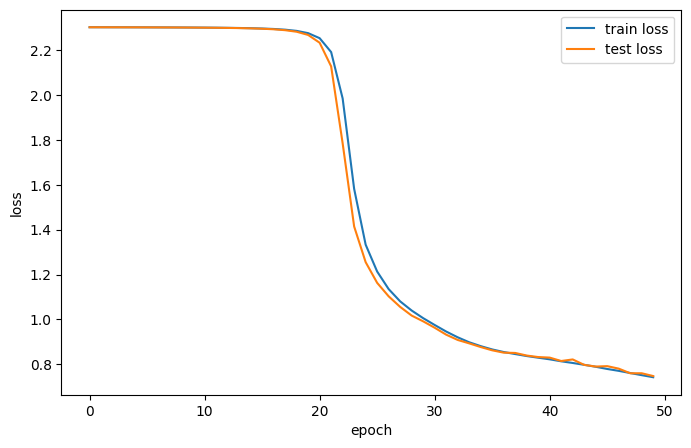

last epoch:
50 0.7422295405509624
50 0.7474099650979042 0.7284


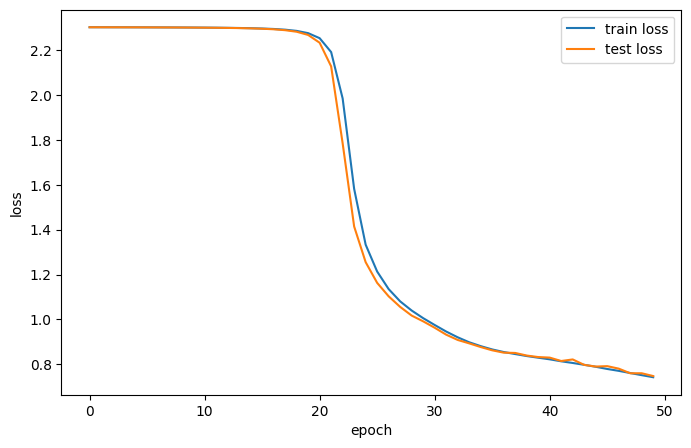

In [33]:
test_acc = []
train_loss, test_loss = train(net, train_iter, test_iter, 0.01, 50)
print('last epoch:')
print(train_loss[-1][0] + 1, train_loss[-1][1])
print(test_loss[-1][0] + 1, test_loss[-1][1], test_acc[-1])
epochs = [p[0] for p in train_loss]
tr = [p[1] for p in train_loss]
te = [p[1] for p in test_loss]
plot_loss_history({'train loss': tr, 'test loss': te})

## 超参数调试小实验（动手实验，填表记录）

每做一个实验：**改一个超参数 → 重跑训练 → 记录最终测试准确率**。多个实验的损失曲线可用 `plot_loss_history({'实验A': hA, '实验B': hB})` 画在同一张图对比。

| # | 实验 | 改动 | 最终测试准确率 |
|---|---|---|---|
| 1 | 批大小 | batch_size ∈ {64, 256, 1024} |0.84, 0.737, 0.6132 |
| 2 | 优化器 | SGD vs Adam |0.8366, 0.8583 |
| 3 | 学习率 | Adam 下 lr ∈ {0.1, 0.01, 0.001} |0.1, 0.887, 0.8681 |
| 4 | 池化方式 | MaxPool vs AvgPool |0.8619, 0.8387 |
| 5 | 激活函数 | ReLU vs Sigmoid |0.8541, 0.1 |

**【你的实验结论】**（哪个超参数影响最大？你试出的最优组合是什么？）

最优组合：Adam + lr=0.01 + MaxPool + ReLU + batch=64，测试准确率约 0.887。 影响最大的是学习率和激活函数——lr=0.1 直接发散到随机（0.1），Sigmoid 因梯度消失完全学不动（0.1），这两个是"决定成败"的旋钮；batch_size 和池化方式影响较小（都在 0.61~0.86 内）。

In [31]:
def evaluate_acc(rightsample, totalsample):
    roundary_acc = rightsample / totalsample
    test_acc.append(roundary_acc)

数据读取完成：训练集批数 235  测试集批数 40
utils.visualization 导入成功: Animator plot_loss_history
relu final_test acc: 0.8541
sigmoid final_test acc: 0.1


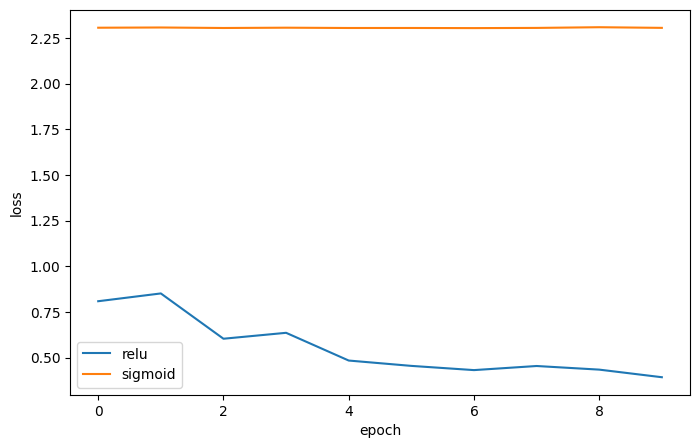

In [50]:
# 实验区：改超参数 → 训练 → 记录（复用你的 train 函数）
%matplotlib inline
import sys, torch
from torch import nn
import torchvision
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt  

# 上溯两级到 Deep-Learning 主目录，导入自己的 utils
sys.path.append('../../')
from utils.visualization import Animator, plot_loss_history
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train(net, train_iter, test_iter, lr, num_epochs, optim):
    net.to(device)
    train_loss = []
    test_loss = []
    loss = nn.CrossEntropyLoss()
    if optim == 'SGD':
        trainer = torch.optim.SGD(net.parameters(), lr = lr)
    else:
        trainer = torch.optim.Adam(net.parameters(), lr = lr)
    for epoch in range(num_epochs):
        epoch_l = 0.0
        epoch_n = 0
        net.train()
        for X, y in train_iter:
            y_hat = net(X.to(device))
            l = loss(y_hat, y.to(device))
            trainer.zero_grad()
            l.backward()
            trainer.step()
            epoch_l += l.item()
            epoch_n += 1
        avg_train_loss = epoch_l / epoch_n

        test_l, test_n = 0.0, 0
        net.eval()
        correct_num = 0
        total_num = 0
        for X, y in test_iter:
            with torch.no_grad():
                y_hat = net(X.to(device))
                l = loss(y_hat, y.to(device))
                test_l += l.item()
                test_n += 1
                total_num += y.numel()
                correct_num += (y_hat.argmax(dim = 1) == y.to(device)).sum().item()
                
        avg_test_loss = test_l / test_n
        evaluate_acc(correct_num, total_num)

        train_loss.append((epoch, avg_train_loss))
        test_loss.append((epoch, avg_test_loss))

    return train_loss, test_loss

def load_data(batch_size):
    trans = transforms.ToTensor()
    tr = torchvision.datasets.FashionMNIST(root='../data', train=True, transform=trans, download=True)
    te = torchvision.datasets.FashionMNIST(root='../data', train=False, transform=trans, download=True)
    return (data.DataLoader(tr, batch_size, shuffle=True),
            data.DataLoader(te, batch_size, shuffle=False))

def make_net(func_type, pool_type):
    if func_type == 'relu':
        if pool_type == 'avgpool':
            net = nn.Sequential(nn.Conv2d(1, 6, 5, padding = 2),
                                nn.ReLU(),
                                nn.AvgPool2d(2, 2),
                    
    
                                nn.Conv2d(6, 16, 5),
                                nn.ReLU(),
                                nn.AvgPool2d(2, 2),
    
                                nn.Flatten(),
                                nn.Linear(16 * 5 * 5, 120),
                                nn.ReLU(),
                                nn.Linear(120, 84),
                                nn.ReLU(),
                                nn.Linear(84, 10))
        else:
            net = nn.Sequential(nn.Conv2d(1, 6, 5, padding = 2),
                                nn.ReLU(),
                                nn.MaxPool2d(2, 2),
                    
    
                                nn.Conv2d(6, 16, 5),
                                nn.ReLU(),
                                nn.MaxPool2d(2, 2),
    
                                nn.Flatten(),
                                nn.Linear(16 * 5 * 5, 120),
                                nn.ReLU(),
                                nn.Linear(120, 84),
                                nn.ReLU(),
                                nn.Linear(84, 10))
    else:
        if pool_type == 'avgpool':
            net = nn.Sequential(nn.Conv2d(1, 6, 5, padding = 2),
                                nn.Sigmoid(),
                                nn.AvgPool2d(2, 2),
                    
    
                                nn.Conv2d(6, 16, 5),
                                nn.Sigmoid(),
                                nn.AvgPool2d(2, 2),
    
                                nn.Flatten(),
                                nn.Linear(16 * 5 * 5, 120),
                                nn.Sigmoid(),
                                nn.Linear(120, 84),
                                nn.Sigmoid(),
                                nn.Linear(84, 10))
        else:
            net = nn.Sequential(nn.Conv2d(1, 6, 5, padding = 2),
                                nn.Sigmoid(),
                                nn.MaxPool2d(2, 2),
                    
    
                                nn.Conv2d(6, 16, 5),
                                nn.Sigmoid(),
                                nn.MaxPool2d(2, 2),
    
                                nn.Flatten(),
                                nn.Linear(16 * 5 * 5, 120),
                                nn.Sigmoid(),
                                nn.Linear(120, 84),
                                nn.Sigmoid(),
                                nn.Linear(84, 10))
    return net

def evaluate_acc(rightsample, totalsample):
    roundary_acc = rightsample / totalsample
    test_acc.append(roundary_acc)

#main func
    #for data loader
train_iter, test_iter = load_data(256)
print('数据读取完成：训练集批数', len(train_iter), ' 测试集批数', len(test_iter))
print('utils.visualization 导入成功:', Animator.__name__, plot_loss_history.__name__)

    #batch_size experiment
'''
batch_sizes = [64, 256, 1024]
batch_size_loss = []
for batch_size in batch_sizes:
    net = make_net('relu', 'avgpool')
    test_acc = []
    train_iter, test_iter = load_data(batch_size)
    train_loss, test_loss = train(net, train_iter, test_iter, 0.01, 15, 'SGD')
    print(f'batch_size{batch_size} final_test acc: {test_acc[-1]}')
    batch_size_loss.append(test_loss)

tbs64 = [l for _, l in batch_size_loss[0]] 
tbs256 = [l for _, l in batch_size_loss[1]]
tbs1024 = [l for _, l in batch_size_loss[2]]
plot_loss_history({'batch_size64':tbs64, 'batch_size256':tbs256, 'batch_size1024':tbs1024})
'''
    #optim experiment
'''
optim_loss = []
optimlist = [(0.1, 'SGD'), (0.001, 'Adam')]
for optim in optimlist:
    test_acc = []
    net = make_net('relu', 'avgpool')
    train_loss, test_loss = train(net, train_iter, test_iter, optim[0], 10, optim[1])
    print(f'{optim} final_test acc: {test_acc[-1]}')
    optim_loss.append(test_loss)

sgd = [l for _, l in optim_loss[0]]
adam = [l for _, l in optim_loss[1]]
plot_loss_history({'sgd':sgd, 'adam':adam})
'''
    #lr experiment
'''
lrs = [0.1, 0.01, 0.001]
lr_loss = []
for lr in lrs:
    test_acc = []
    net = make_net('relu', 'avgpool')
    train_loss, test_loss = train(net, train_iter, test_iter, lr, 10, 'Adam')
    print(f'{lr} final_test acc: {test_acc[-1]}')
    lr_loss.append(test_loss)

lr_01 = [l for _, l in lr_loss[0]]
lr_001 = [l for _, l in lr_loss[1]]
lr_0001 = [l for _, l in lr_loss[2]]
plot_loss_history({'lr_0.1':lr_01, 'lr_0.01':lr_001, 'lr_0.001':lr_0001})
'''
    #pool experiment
'''
pool_types = ['avgpool', 'maxpool']
pool_loss = []
for pool_type in pool_types:
    test_acc = []
    net = make_net('relu', pool_type)
    train_loss, test_loss = train(net, train_iter, test_iter, 0.1, 10, 'SGD')
    print(f'{pool_type} final_test acc: {test_acc[-1]}')
    pool_loss.append(test_loss)

avg = [l for _, l in pool_loss[0]]
max = [l for _, l in pool_loss[1]]
plot_loss_history({'avgpool':avg, 'maxpool':max})
'''
    #actfunc experiment
afs = ['relu', 'sigmoid']
af_loss = []
for af in afs:
    test_acc = []
    net = make_net(af, 'avgpool')
    train_loss, test_loss = train(net, train_iter, test_iter, 0.1, 10, 'SGD')
    print(f'{af} final_test acc: {test_acc[-1]}')
    af_loss.append(test_loss)

relu = [l for _, l in af_loss[0]]
sigmoid = [l for _, l in af_loss[1]]
plot_loss_history({'relu':relu, 'sigmoid':sigmoid})

## 以下是对应的输出：
不难发现batchsize越大，模型学的越不好，所以选取一个适当的batchsize是有必要的

optimizer不同，收敛的速度和震荡程度不同

不同lr影响很大，尤其在0.1处模型基本上没有进行有效学习

## Batchsize_exp
### Epoch = 10
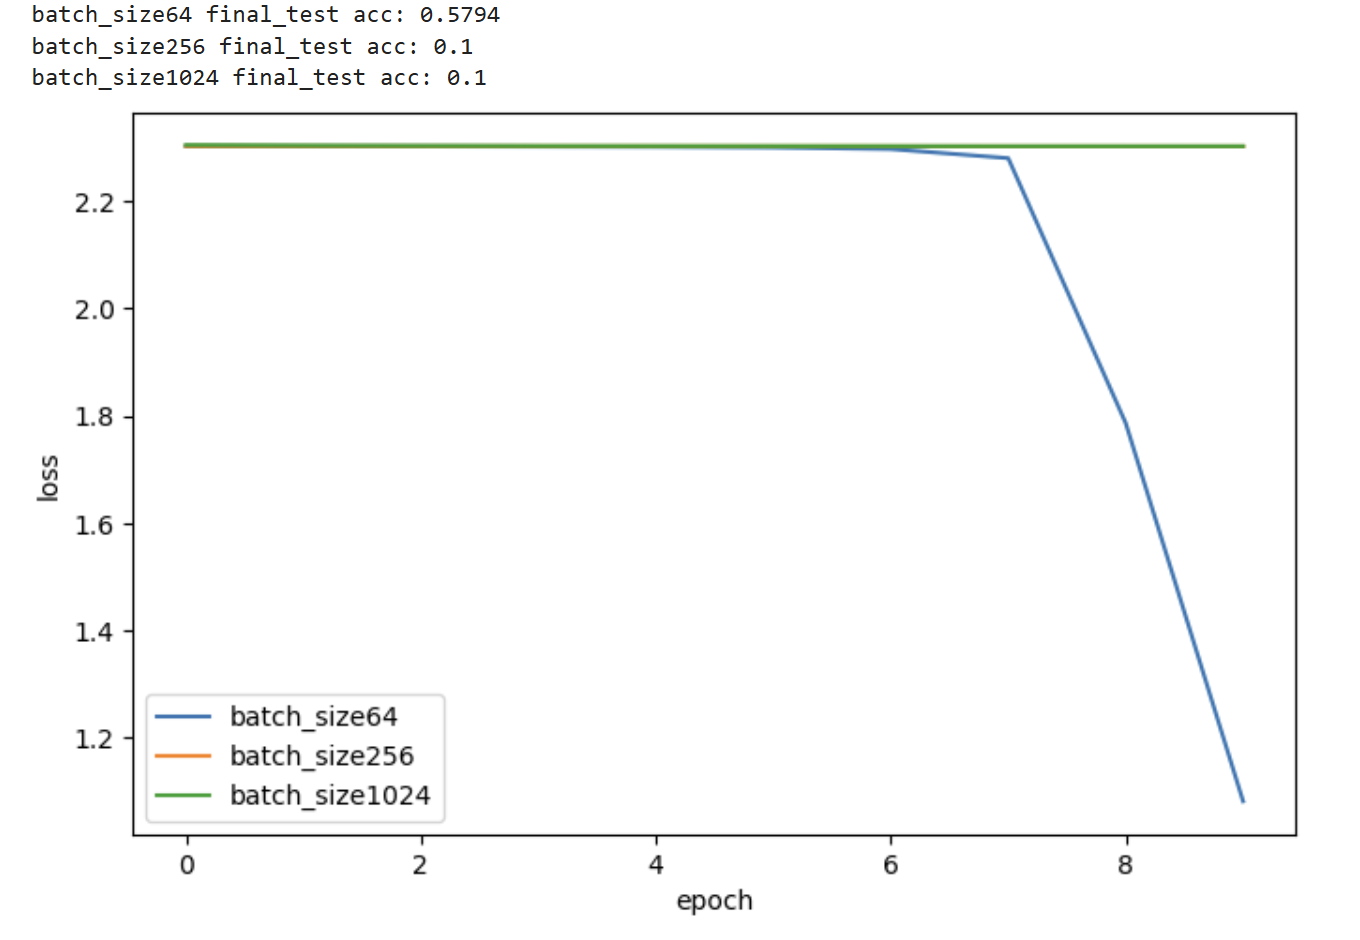

### Epoch = 15
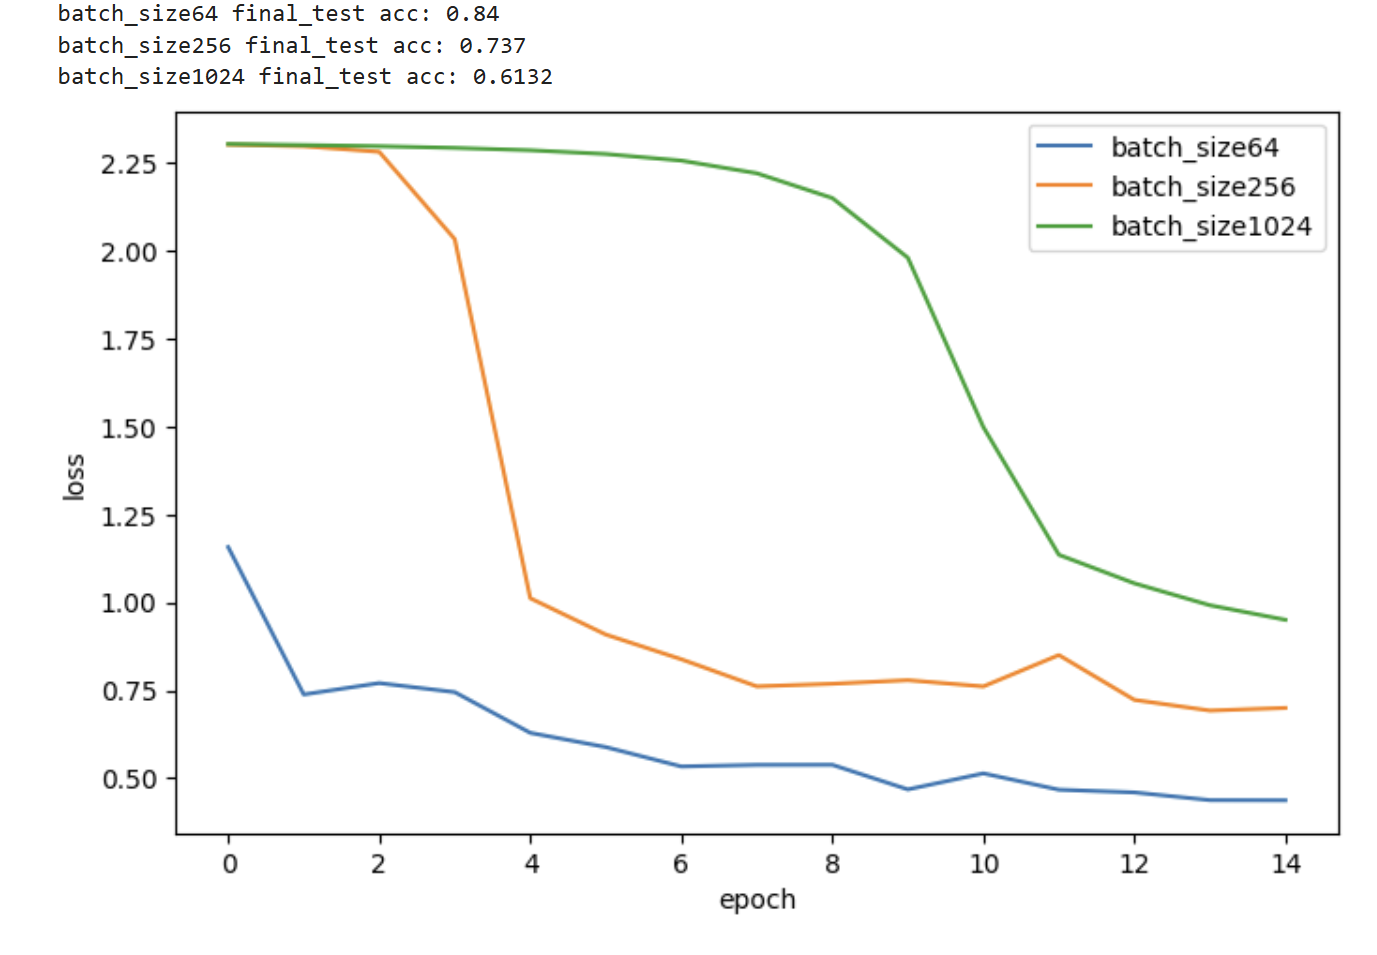

## optimizer_exp
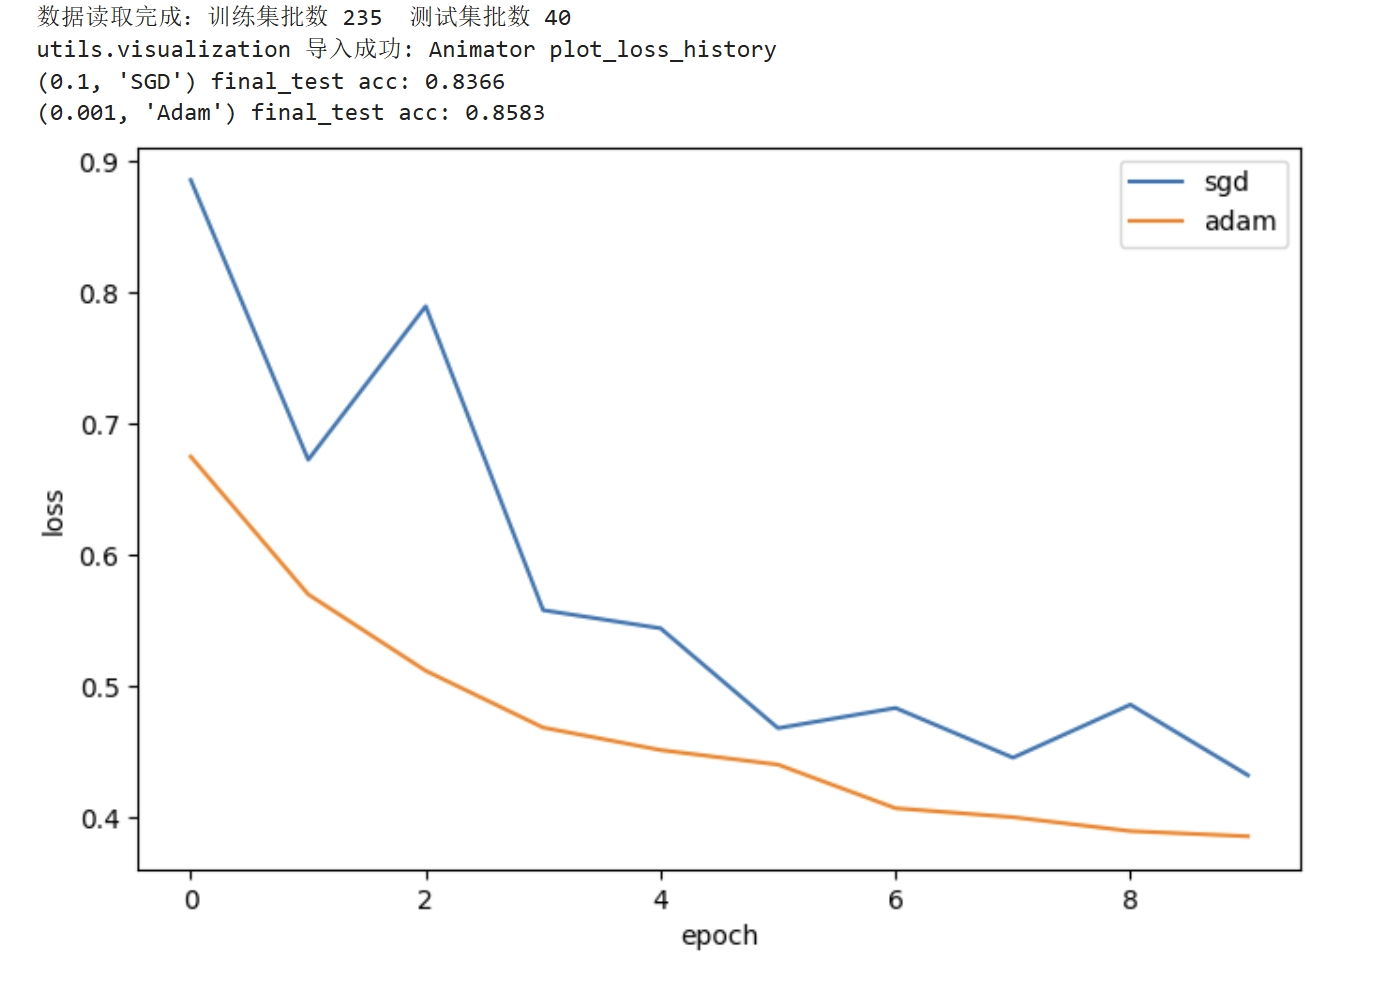

## lr_exp
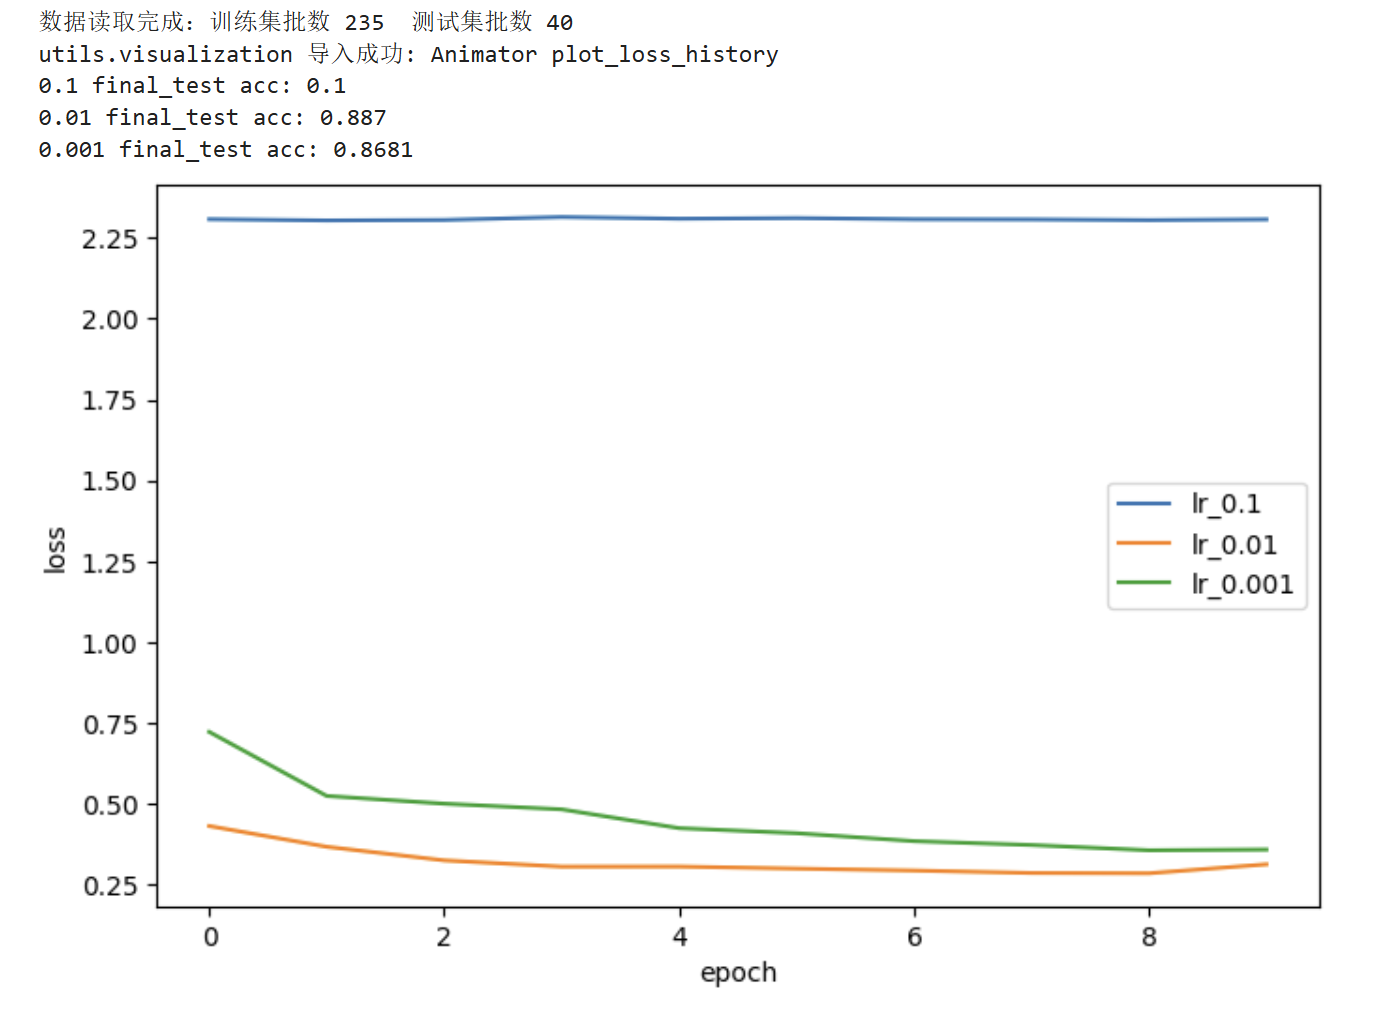

## pooling_exp
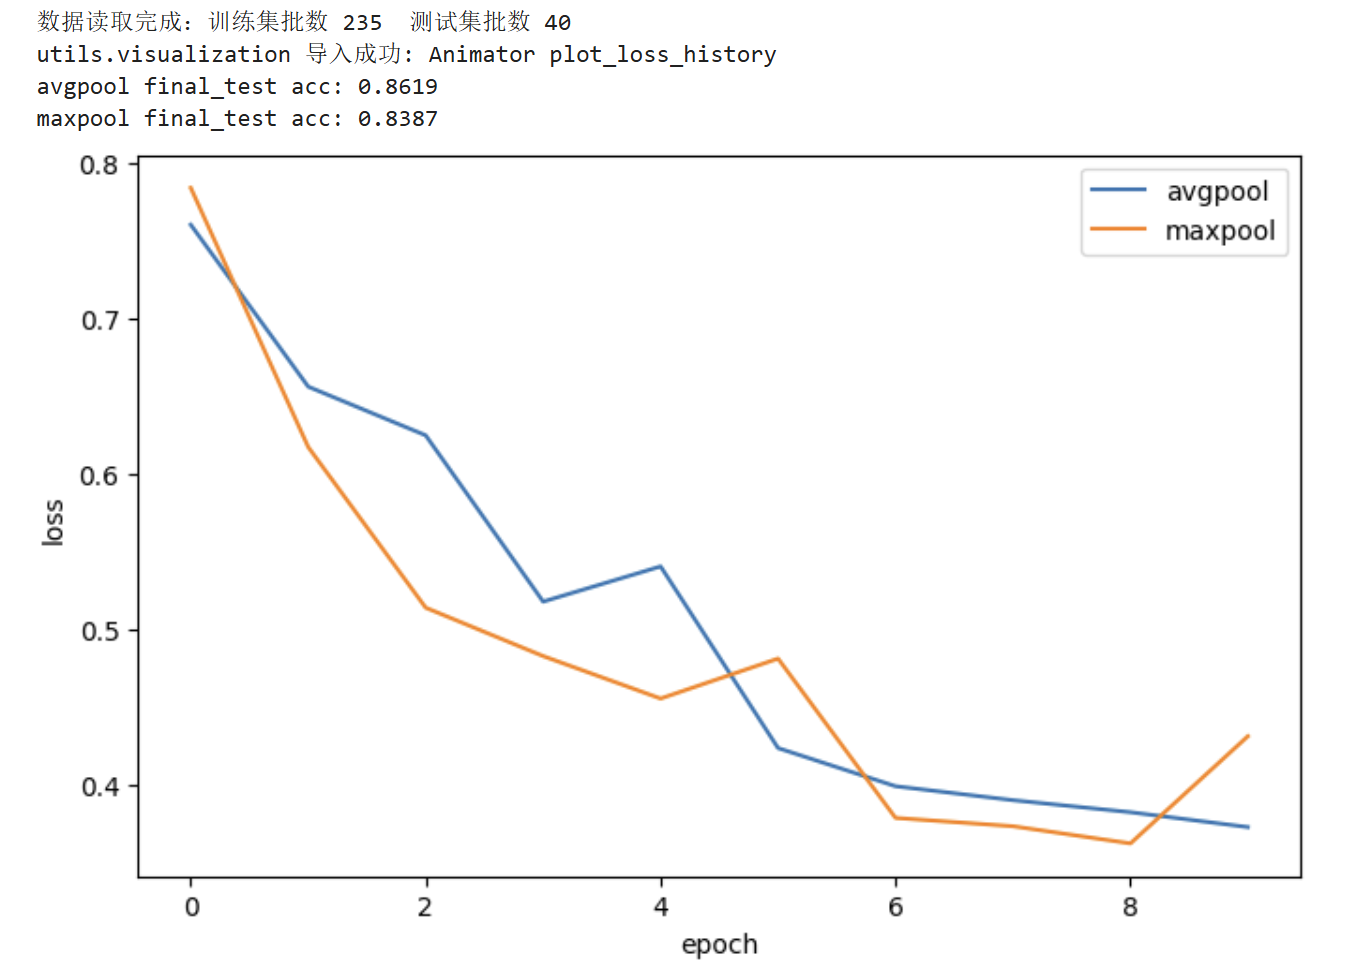

## activatefunc_exp
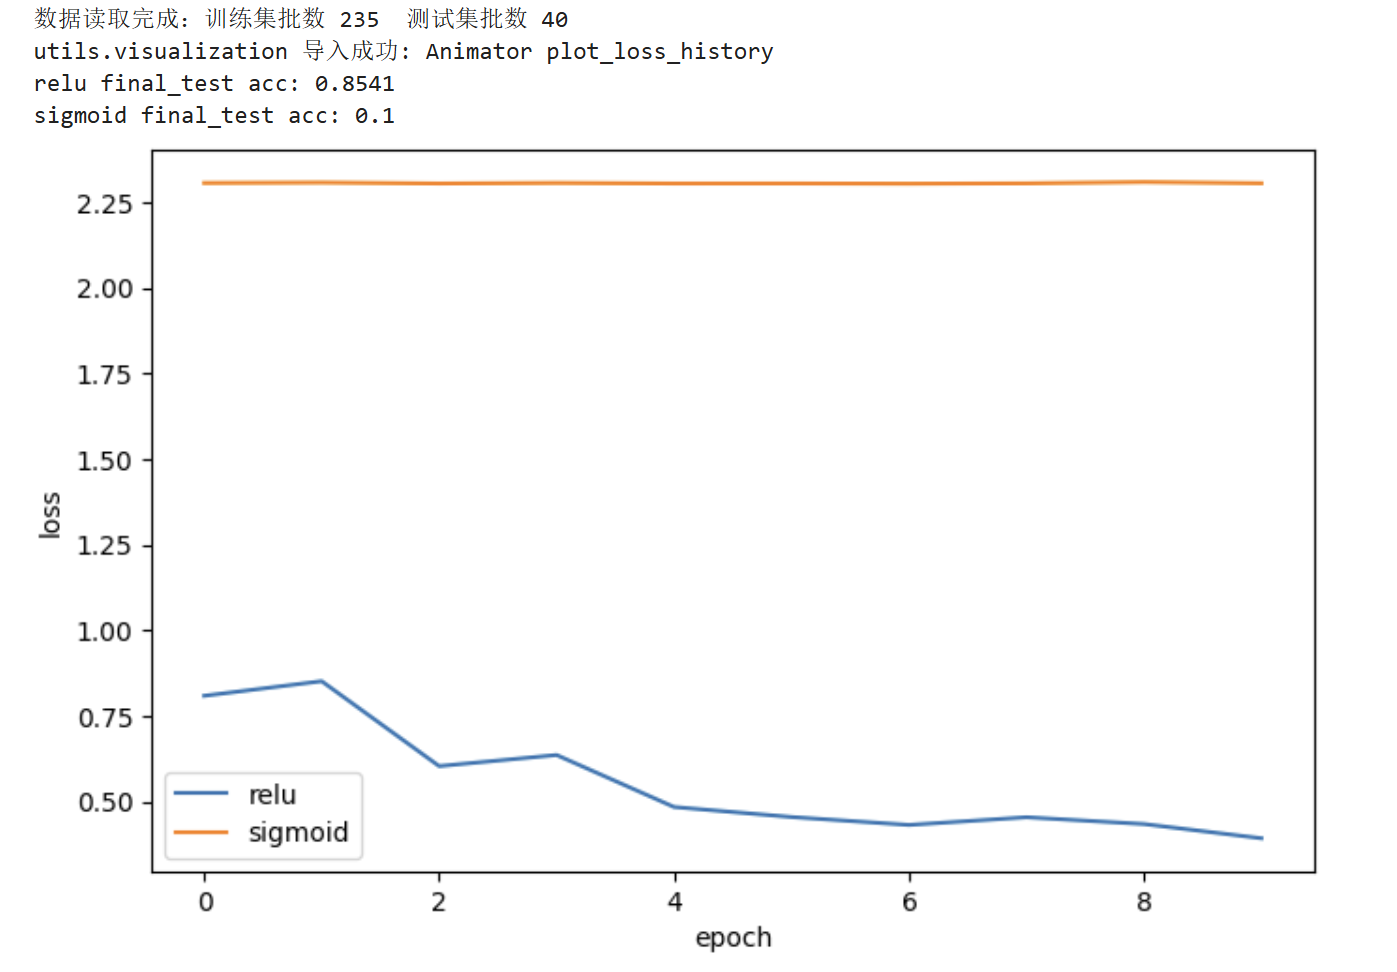